In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar a base de dados
file_path = r"C:\Users\lucas\Downloads\Case Sarpen\Sarpen_Trabalho.xlsx"
df = pd.read_excel(file_path)

# Exibir as primeiras linhas do DataFrame
print(df.head())  # Para ver as primeiras 5 linhas do arquivo

  Unnamed: 0  IPCA  IPCA.1  IPCA_QoQ  selic goal         gdp            PO  \
0 2004-01-31  0.76    6.03       NaN      0.1650         NaN           NaN   
1 2004-02-29  0.61    5.64       NaN      0.1650         NaN           NaN   
2 2004-03-31  0.47    5.54  1.851097      0.1625  120.503502  7.652209e+07   
3 2004-04-30  0.37    5.60       NaN      0.1600         NaN           NaN   
4 2004-05-31  0.51    5.95       NaN      0.1600         NaN           NaN   

            PEA  Taxa de desemprego  NUCI   ibc_b  
0           NaN                 NaN  81.8   98.59  
1           NaN                 NaN  81.6   99.45  
2  8.567001e+07            0.106781  81.4  111.98  
3           NaN                 NaN  80.5  107.36  
4           NaN                 NaN  80.6  106.03  


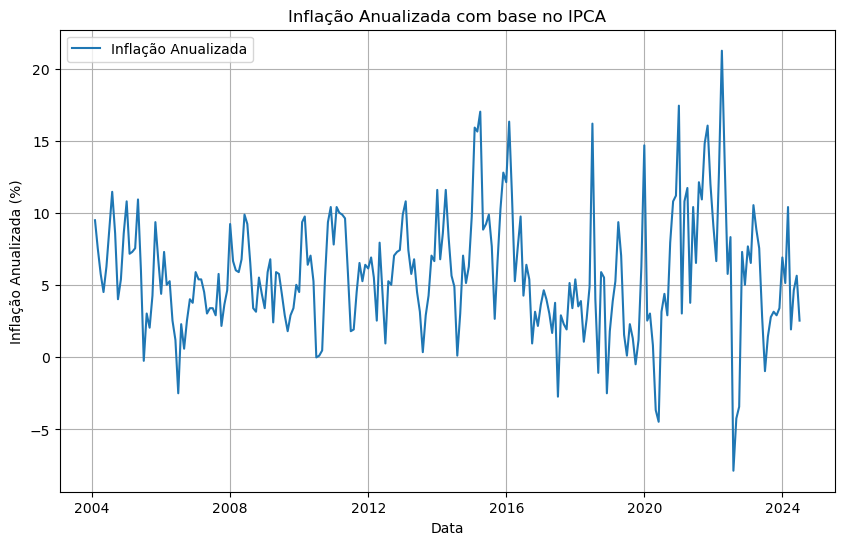

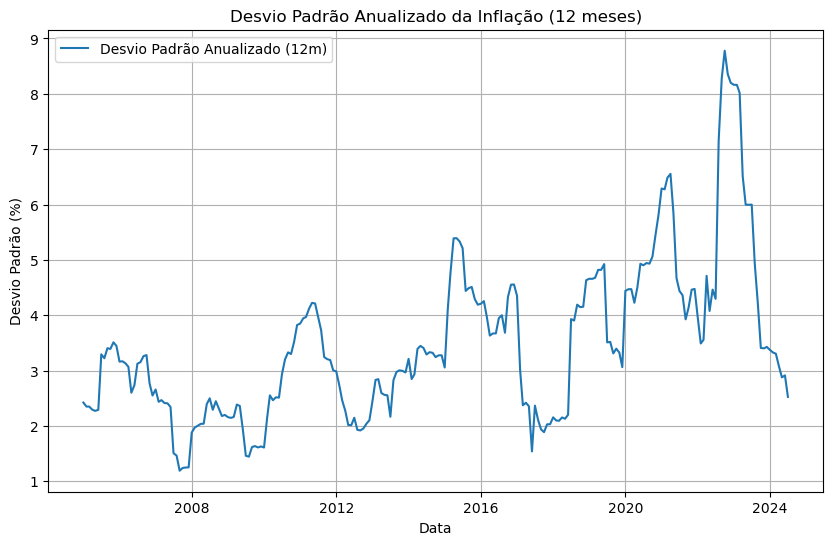

In [19]:
# Convertendo a coluna 'Unnamed: 0' (datas) para datetime e definindo como índice
df['Unnamed: 0'] = pd.to_datetime(df['Unnamed: 0'])
df.set_index('Unnamed: 0', inplace=True)

# Calcular a inflação anualizada (utilizando IPCA)
df['IPCA_anualizada'] = ((1 + df['IPCA']/100)**12 - 1) * 100

# Gráfico da inflação anualizada
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['IPCA_anualizada'], label='Inflação Anualizada')
plt.title('Inflação Anualizada com base no IPCA')
plt.xlabel('Data')
plt.ylabel('Inflação Anualizada (%)')
plt.legend()
plt.grid(True)
plt.show()

# Calcular o desvio padrão móvel de 12 meses
df['IPCA_std_12m'] = df['IPCA_anualizada'].rolling(window=12).std()

# Gráfico do desvio padrão
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['IPCA_std_12m'], label='Desvio Padrão Anualizado (12m)')
plt.title('Desvio Padrão Anualizado da Inflação (12 meses)')
plt.xlabel('Data')
plt.ylabel('Desvio Padrão (%)')
plt.legend()
plt.grid(True)
plt.show()


In [36]:
import pandas as pd
import statsmodels.api as sm

# Carregar a base de dados
file_path = r"C:\Users\lucas\Downloads\Case Sarpen\Sarpen_Trabalho.xlsx"
df = pd.read_excel(file_path)

# Remover linhas com NaN ou valores infinitos em qualquer coluna e usar somente trimestre
df_clean = df.replace([float('inf'), float('-inf')], pd.NA).dropna()

# Separar as variáveis dependentes e independentes
y = df_clean['IPCA_QoQ']  # Variável dependente (ajuste conforme necessário)
X = df_clean[['selic goal', 'gdp', 'PO', 'Taxa de desemprego']]  # Variáveis independentes

# Adicionar constante
X = sm.add_constant(X)

# Regressão linear
model = sm.OLS(y, X).fit()

# Resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               IPCA_QoQ   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     1.822
Date:                Mon, 16 Dec 2024   Prob (F-statistic):              0.133
Time:                        22:18:26   Log-Likelihood:                -96.618
No. Observations:                  82   AIC:                             203.2
Df Residuals:                      77   BIC:                             215.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.7876      2